In [32]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns 

In [33]:
df = pd.read_csv('churn.csv')
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [34]:
df['Exited'].value_counts()

Exited
0    7963
1    2037
Name: count, dtype: int64

# data types & Details 
1. row number is unique value 
2. CustomerId is also unique value 
3. surname is also the unique value 
4. credit score is numerical continious value 
5. geograpy is catagorical nominal value 
6. gender is catagorical nominal value 
7. age is numerical continious value 
8. tenure (number of year that customer has been client of bank) is categorical ordinal value 
9. balance is numerical continious value 
10. NumOfProducts is catagorical ordinal value 
11. HasCrCard is catagorical nominal value 
12. is active is catagorical nominal value 
13. Estimated salary is numerical continious value 
14. Exited (whether or not the customer left the bank.) is catagorical nominal  value where 1 = yes and 0 = no 

In [35]:
df['Tenure'].value_counts()

Tenure
2     1048
1     1035
7     1028
8     1025
5     1012
3     1009
4      989
9      984
6      967
10     490
0      413
Name: count, dtype: int64

In [36]:
# count occurrences of each Geography / IsActiveMember combination
df.groupby(['Geography', 'IsActiveMember']).size().reset_index(name='count')

,Geography,IsActiveMember,count
0,France,0,2423
1,France,1,2591
2,Germany,0,1261
3,Germany,1,1248
4,Spain,0,1165
5,Spain,1,1312


In [37]:
df['Exited'].value_counts()

Exited
0    7963
1    2037
Name: count, dtype: int64

In [38]:
# rows and columns details 
rows, cols = df.shape
print(f"Rows: {rows}\nColumns: {cols}")

Rows: 10000
Columns: 14


In [39]:
# data info 
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  str    
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  str    
 5   Gender           10000 non-null  str    
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), str(3)
memory usage: 1.2 MB


In [40]:
# checking for missing values
df.isnull().sum()

RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

In [41]:
# checking for duplicate values
df.duplicated().sum()

np.int64(0)

In [42]:
# quick statistics summary 
df.describe()

,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.00000,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,5000.50000,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,2886.89568,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.00000,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,2500.75000,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,5000.50000,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,7500.25000,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,10000.00000,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


 # Univariable analysis 

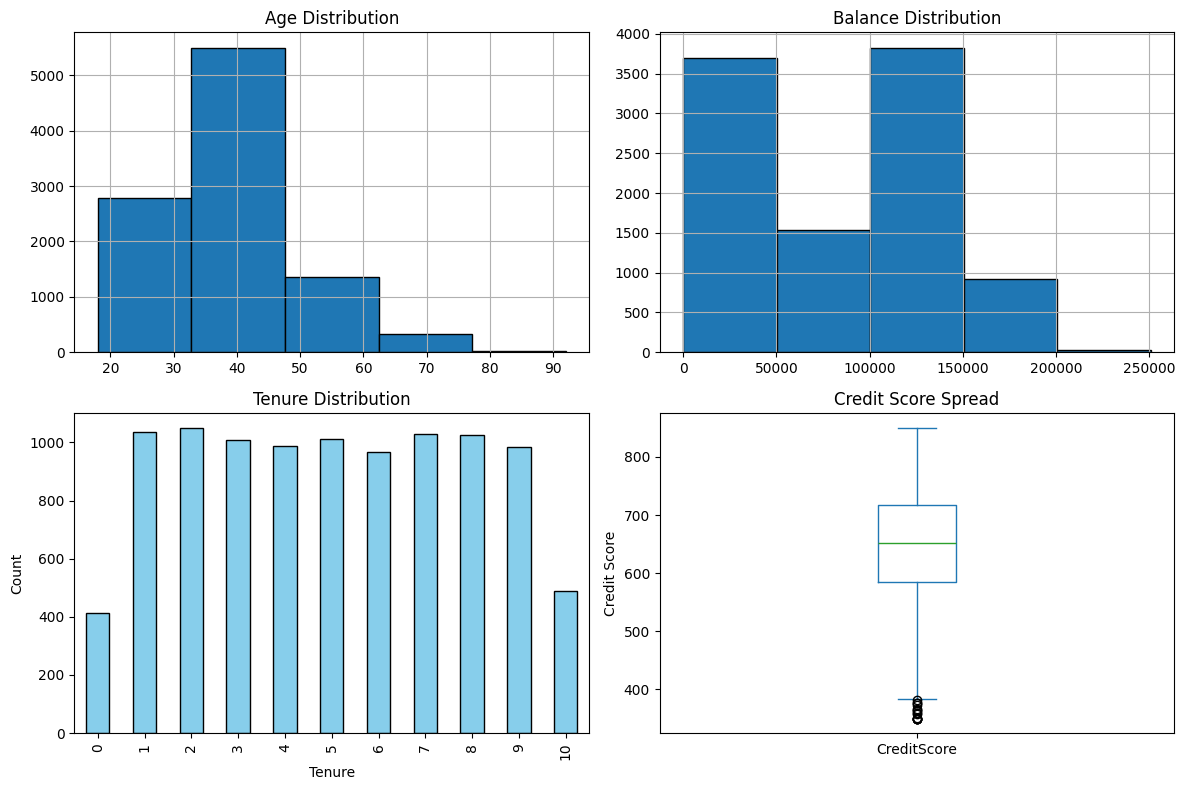

In [43]:


fig, axes = plt.subplots(2, 2, figsize=(12, 8))  # 2 rows × 2 columns

# Chart 1: Age Histogram
df['Age'].hist(bins=5, edgecolor='black', ax=axes[0,0])
axes[0,0].set_title("Age Distribution")

# Chart 2: Balance Histogram
df['Balance'].hist(bins=5, edgecolor='black', ax=axes[0,1])
axes[0,1].set_title("Balance Distribution")

# Chart 3: Tenure Bar Chart
df['Tenure'].value_counts().sort_index().plot.bar(
    color='skyblue', edgecolor='black', ax=axes[1,0]
)
axes[1,0].set_title("Tenure Distribution")
axes[1,0].set_xlabel("Tenure")
axes[1,0].set_ylabel("Count")

# Chart 4: Credit Score Boxplot
df['CreditScore'].plot(kind='box', ax=axes[1,1])
axes[1,1].set_title("Credit Score Spread")
axes[1,1].set_ylabel("Credit Score")

plt.tight_layout()
plt.show()


# bivaraint analysis 

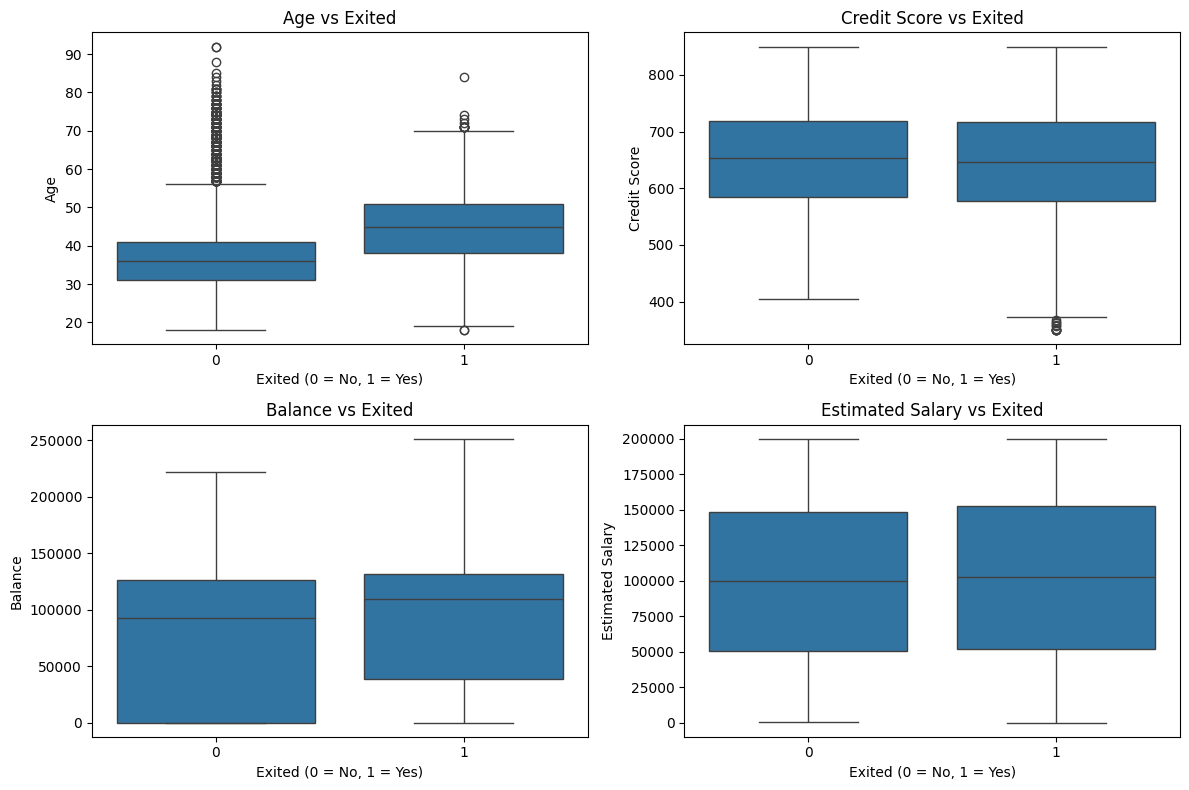

In [44]:

fig, axes = plt.subplots(2, 2, figsize=(12, 8))  # 2 rows × 2 columns

# Chart 1: Age vs Exited
sns.boxplot(x='Exited', y='Age', data=df, ax=axes[0,0])
axes[0,0].set_title("Age vs Exited")
axes[0,0].set_xlabel("Exited (0 = No, 1 = Yes)")
axes[0,0].set_ylabel("Age")

# Chart 2: Credit Score vs Exited
sns.boxplot(x='Exited', y='CreditScore', data=df, ax=axes[0,1])
axes[0,1].set_title("Credit Score vs Exited")
axes[0,1].set_xlabel("Exited (0 = No, 1 = Yes)")
axes[0,1].set_ylabel("Credit Score")

# Chart 3: Balance vs Exited
sns.boxplot(x='Exited', y='Balance', data=df, ax=axes[1,0])
axes[1,0].set_title("Balance vs Exited")
axes[1,0].set_xlabel("Exited (0 = No, 1 = Yes)")
axes[1,0].set_ylabel("Balance")

# Chart 4: Estimated Salary vs Exited
sns.boxplot(x='Exited', y='EstimatedSalary', data=df, ax=axes[1,1])
axes[1,1].set_title("Estimated Salary vs Exited")
axes[1,1].set_xlabel("Exited (0 = No, 1 = Yes)")
axes[1,1].set_ylabel("Estimated Salary")

plt.tight_layout()
plt.show()


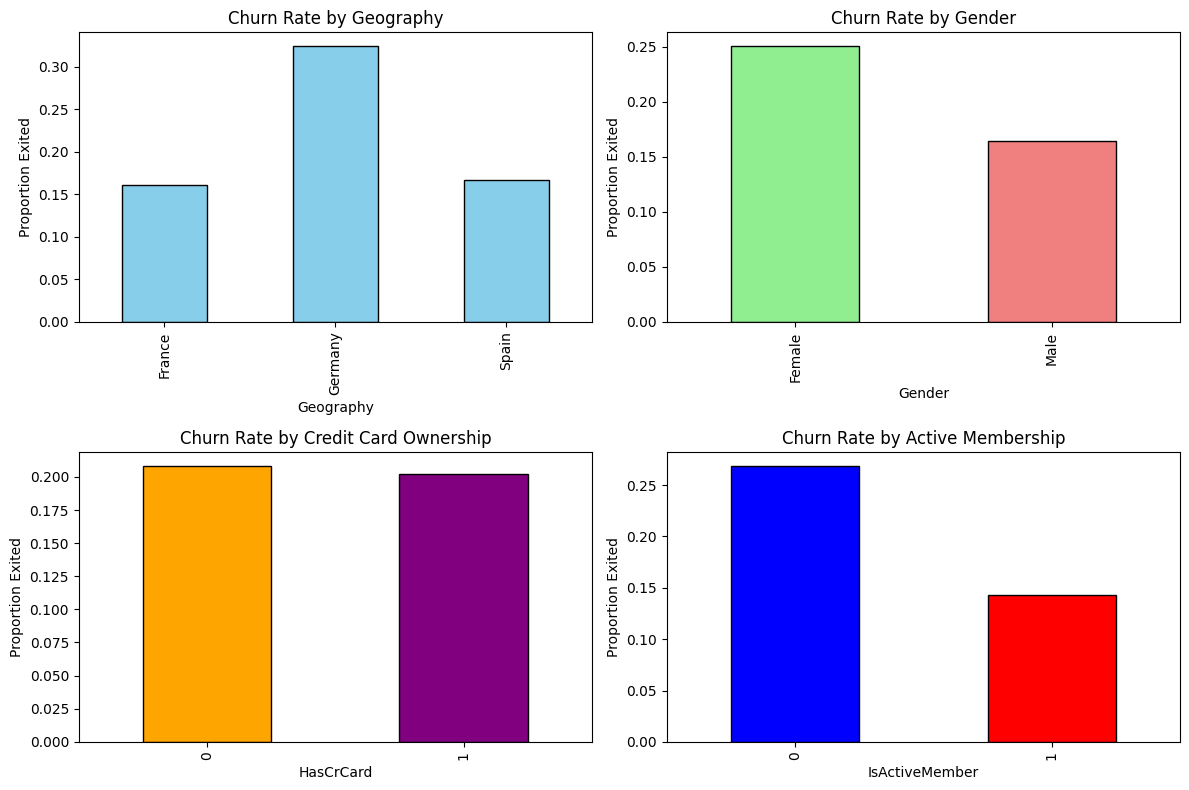

In [45]:

fig, axes = plt.subplots(2, 2, figsize=(12, 8))  # 2 rows × 2 columns

# 1. Geography vs Exited (churn rate per country)
geo_rate = df.groupby('Geography')['Exited'].mean()
geo_rate.plot(kind='bar', ax=axes[0,0], color='skyblue', edgecolor='black')
axes[0,0].set_title("Churn Rate by Geography")
axes[0,0].set_ylabel("Proportion Exited")

# 2. Gender vs Exited (churn rate male vs female)
gender_rate = df.groupby('Gender')['Exited'].mean()
gender_rate.plot(kind='bar', ax=axes[0,1], color=['lightgreen','lightcoral'], edgecolor='black')
axes[0,1].set_title("Churn Rate by Gender")
axes[0,1].set_ylabel("Proportion Exited")

# 3. HasCrCard vs Exited (churn rate with/without credit card)
card_rate = df.groupby('HasCrCard')['Exited'].mean()
card_rate.plot(kind='bar', ax=axes[1,0], color=['orange','purple'], edgecolor='black')
axes[1,0].set_title("Churn Rate by Credit Card Ownership")
axes[1,0].set_ylabel("Proportion Exited")

# 4. IsActiveMember vs Exited (churn rate active vs inactive)
active_rate = df.groupby('IsActiveMember')['Exited'].mean()
active_rate.plot(kind='bar', ax=axes[1,1], color=['blue','red'], edgecolor='black')
axes[1,1].set_title("Churn Rate by Active Membership")
axes[1,1].set_ylabel("Proportion Exited")

plt.tight_layout()
plt.show()


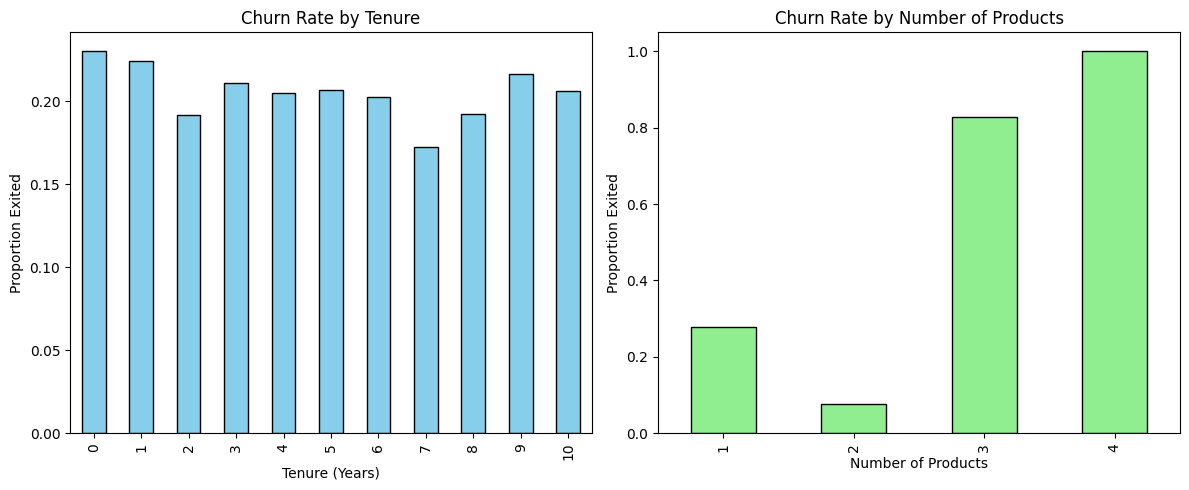

In [46]:


fig, axes = plt.subplots(1, 2, figsize=(12, 5))  # 1 row × 2 columns

# Tenure vs Exited (churn rate per tenure year)
tenure_rate = df.groupby('Tenure')['Exited'].mean()
tenure_rate.plot(kind='bar', ax=axes[0], color='skyblue', edgecolor='black')
axes[0].set_title("Churn Rate by Tenure")
axes[0].set_ylabel("Proportion Exited")
axes[0].set_xlabel("Tenure (Years)")

# NumOfProducts vs Exited (churn rate per product count)
product_rate = df.groupby('NumOfProducts')['Exited'].mean()
product_rate.plot(kind='bar', ax=axes[1], color='lightgreen', edgecolor='black')
axes[1].set_title("Churn Rate by Number of Products")
axes[1].set_ylabel("Proportion Exited")
axes[1].set_xlabel("Number of Products")

plt.tight_layout()
plt.show()


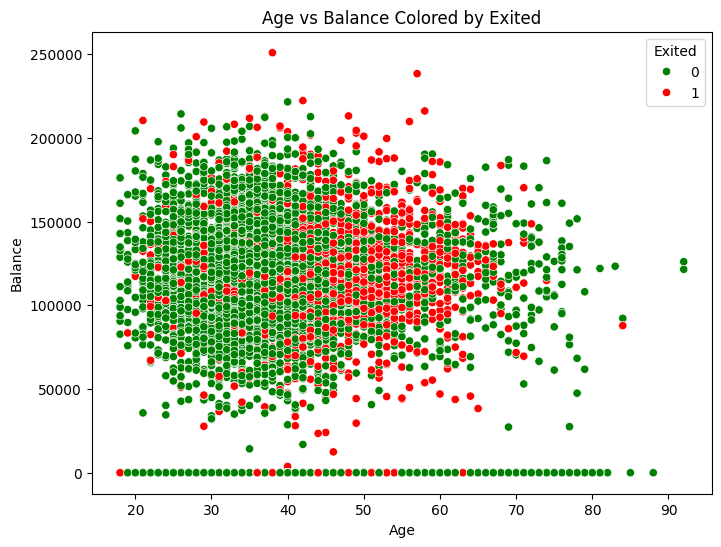

In [47]:
plt.figure(figsize=(8,6))
sns.scatterplot(x='Age', y='Balance', hue='Exited', data=df, palette={0:'green',1:'red'})
plt.title("Age vs Balance Colored by Exited")
plt.xlabel("Age")
plt.ylabel("Balance")
plt.show()

C:\Users\ACER\AppData\Local\Temp\ipykernel_13696\3554853144.py:4: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(x='Geography', y='Exited', hue='Gender', data=df, ci=None)


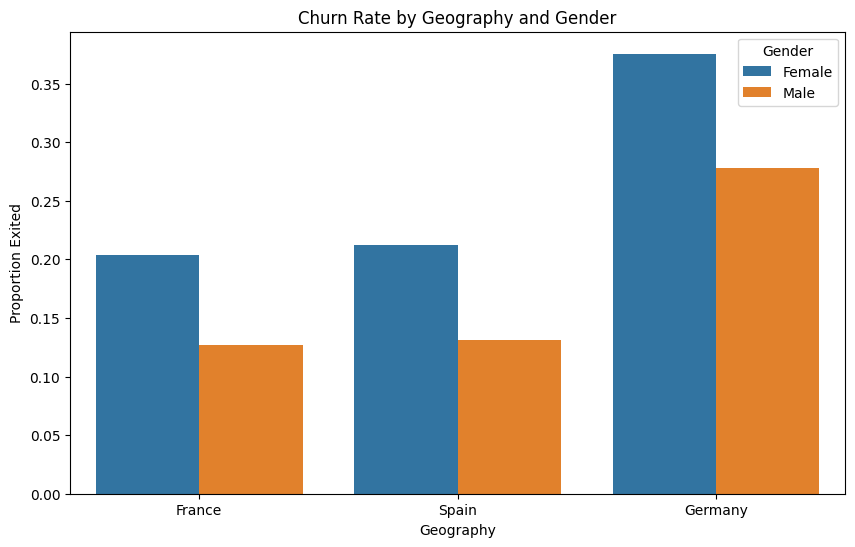

In [48]:
plt.figure(figsize=(10,6))

# Grouped bar chart: Geography + Gender vs churn rate
sns.barplot(x='Geography', y='Exited', hue='Gender', data=df, ci=None)

plt.title("Churn Rate by Geography and Gender")
plt.ylabel("Proportion Exited")
plt.xlabel("Geography")
plt.legend(title="Gender")

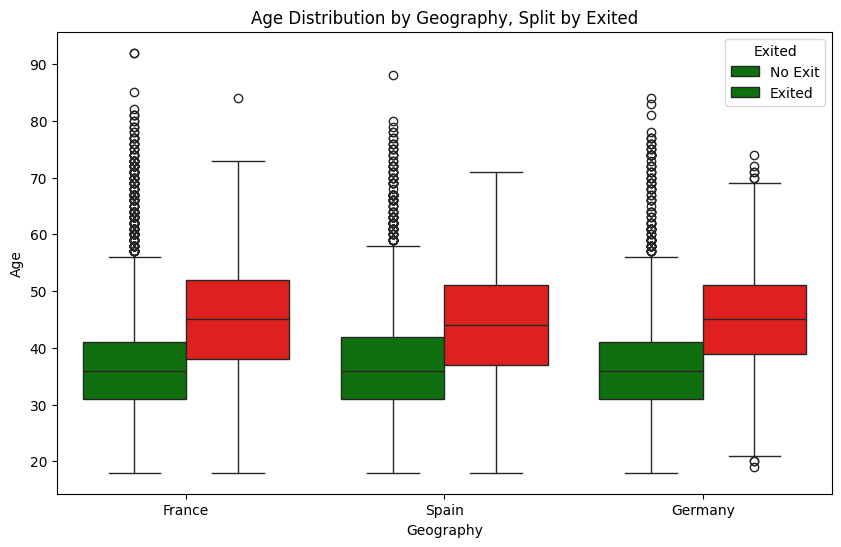

In [49]:
plt.figure(figsize=(10,6))

sns.boxplot(x='Geography', y='Age', hue='Exited', data=df,
            palette={0:'green', 1:'red'})

plt.title("Age Distribution by Geography, Split by Exited")
plt.xlabel("Geography")
plt.ylabel("Age")
plt.legend(title="Exited", labels=["No Exit", "Exited"])
plt.show()

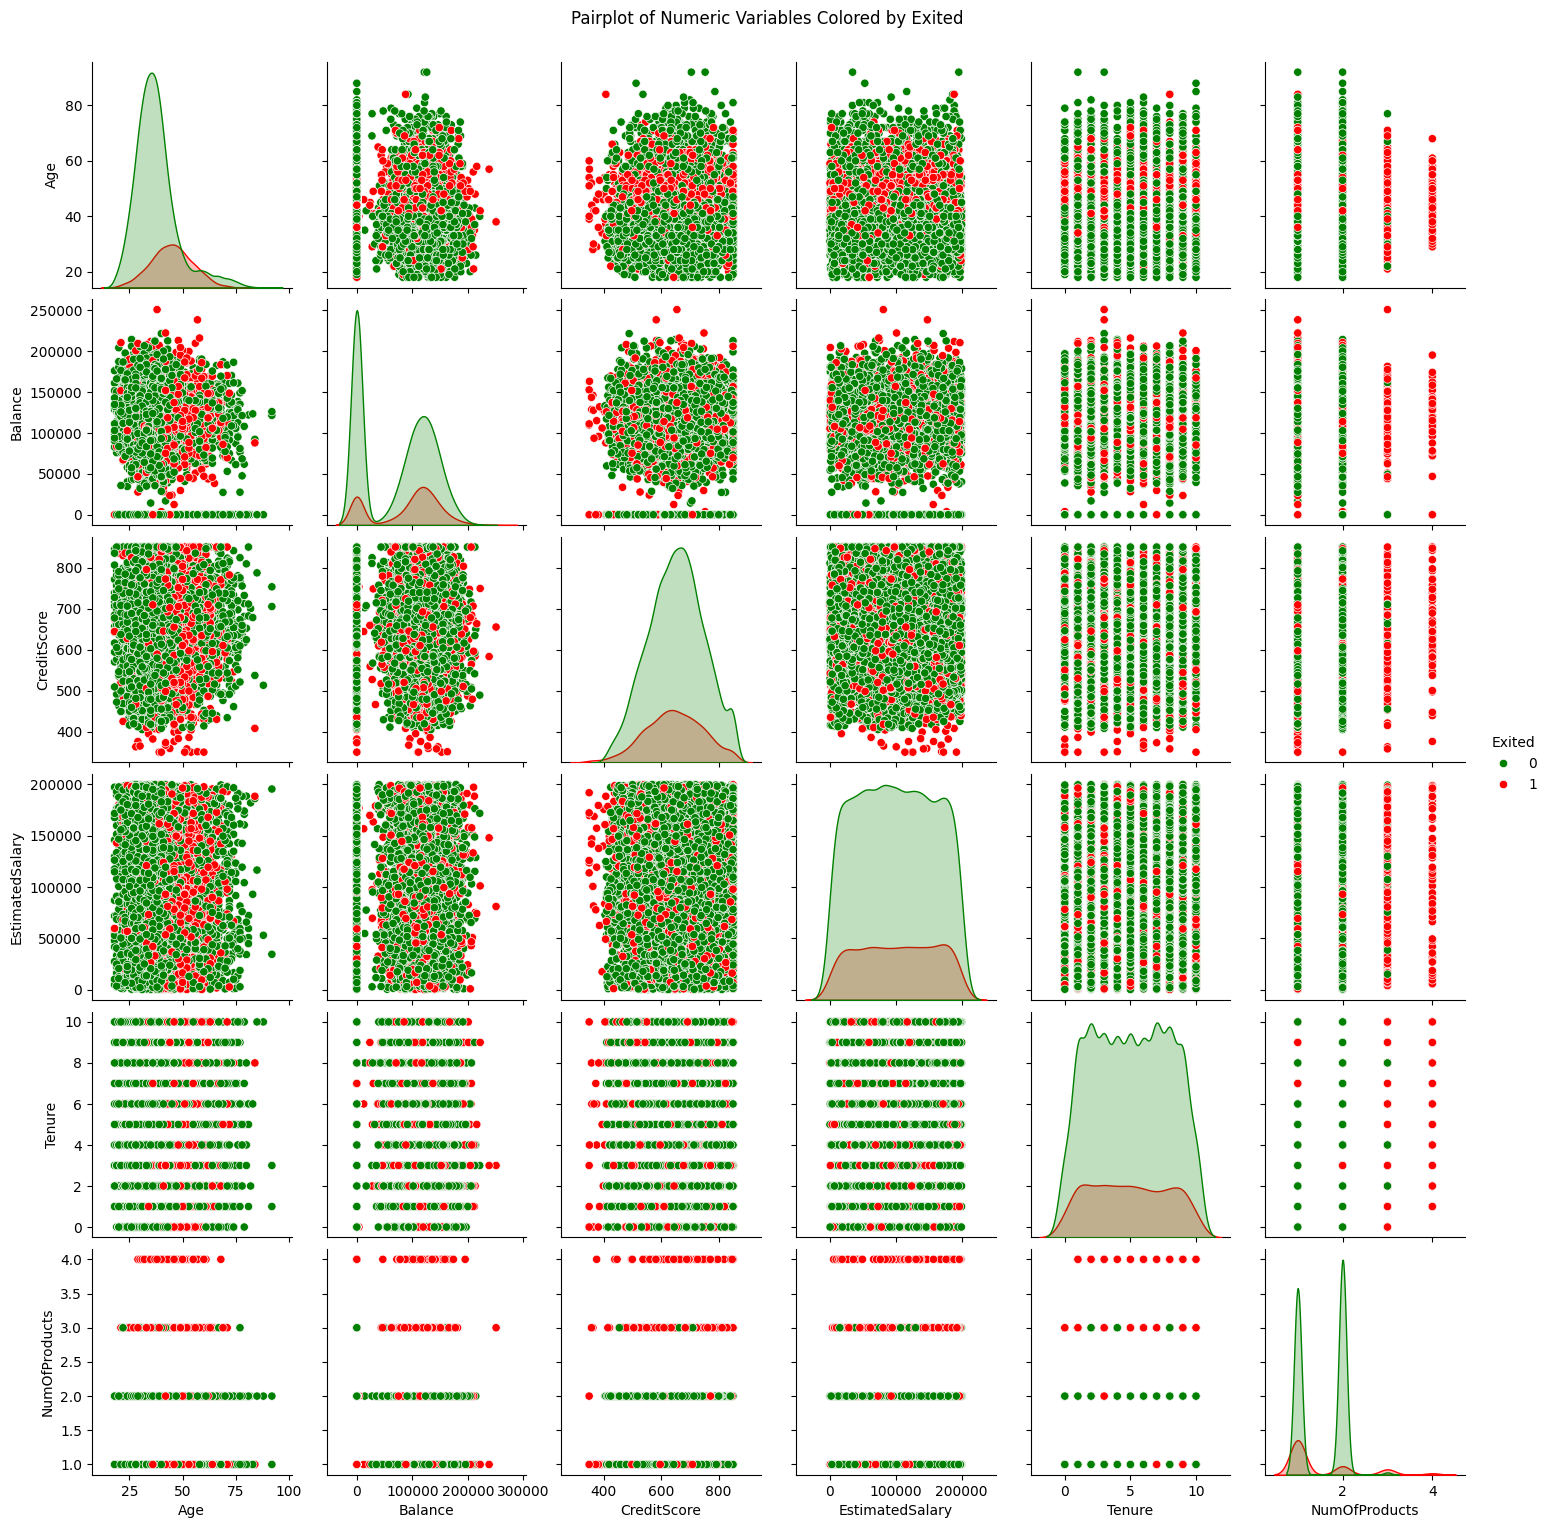

In [50]:

# Select numeric columns + target
numeric_cols = ['Age', 'Balance', 'CreditScore', 'EstimatedSalary', 'Tenure', 'NumOfProducts', 'Exited']

sns.pairplot(df[numeric_cols], hue='Exited', palette={0:'green', 1:'red'})
plt.suptitle("Pairplot of Numeric Variables Colored by Exited", y=1.02)
plt.show()

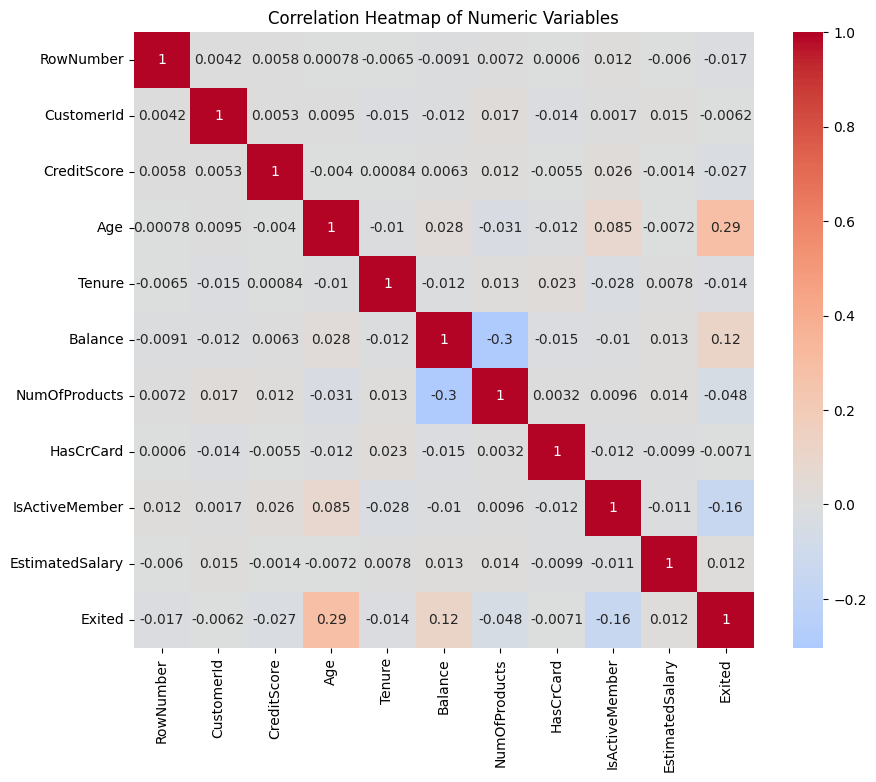

In [51]:
corr = df.select_dtypes(include=[np.number]).corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0)
plt.title("Correlation Heatmap of Numeric Variables")
plt.show()

In [52]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  str    
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  str    
 5   Gender           10000 non-null  str    
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), str(3)
memory usage: 1.2 MB


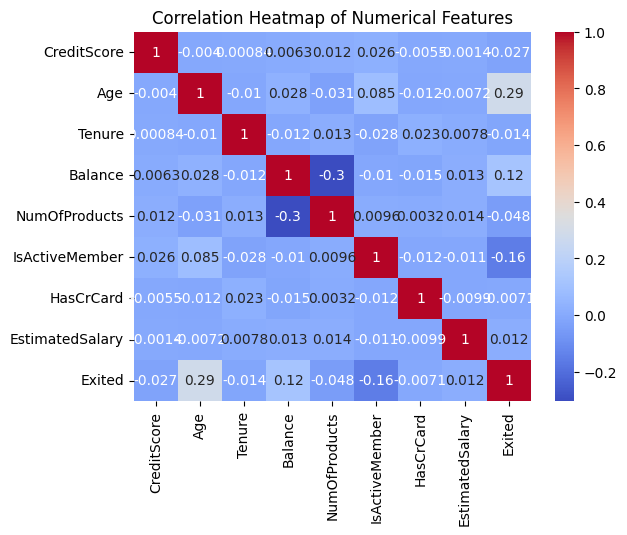

In [53]:
# Correlation heatmap
corr = df[['CreditScore','Age','Tenure','Balance','NumOfProducts','IsActiveMember','HasCrCard','EstimatedSalary', 'Exited']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap of Numerical Features")
plt.show()

In [54]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  str    
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  str    
 5   Gender           10000 non-null  str    
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), str(3)
memory usage: 1.2 MB


In [55]:
# feature encoding 
# 1. Convert 'Gender' from string to binary integers (0 and 1)
df['Gender'] = df['Gender'].map({'Male': 0, 'Female': 1})

# 2. Convert 'Geography' from string to One-Hot Encoded integer columns
df = pd.get_dummies(df, columns=['Geography'], drop_first=True, dtype=int)

In [58]:
import pandas as pd
import numpy as np
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

# 1. Separate Features (X) and Target (y)
X = df.drop(columns=['RowNumber', 'CustomerId', 'Surname', 'Exited'])
y = df['Exited']

# 2. Identify numerical features for scaling
scale_cols = ['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'EstimatedSalary']

# 3. Preprocessor: scale numeric features, keep others as-is
scaler_transformer = ColumnTransformer(
    transformers=[('num_scaler', StandardScaler(), scale_cols)],
    remainder='passthrough'
)

# 4. Define models to compare
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, class_weight='balanced'),
    "Random Forest": RandomForestClassifier(random_state=42, class_weight='balanced'),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42)
}

# 5. Stratified K-Fold setup
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# 6. Scoring metrics
scoring = ['roc_auc', 'f1', 'precision', 'recall']

# 7. Run cross-validation for each model
results = {}
for name, model in models.items():
    pipeline = Pipeline([
        ('scaler', scaler_transformer),
        ('classifier', model)
    ])
    cv_results = cross_validate(pipeline, X, y, cv=skf, scoring=scoring, n_jobs=-1)
    results[name] = {metric: cv_results[f'test_{metric}'].mean() for metric in scoring}

# 8. Print comparison
for model_name, scores in results.items():
    print(f"\n{model_name}")
    for metric, value in scores.items():
        print(f"{metric.upper():<10} | Mean: {value:.4f}")



Logistic Regression
ROC_AUC    | Mean: 0.7693
F1         | Mean: 0.4934
PRECISION  | Mean: 0.3838
RECALL     | Mean: 0.6912

Random Forest
ROC_AUC    | Mean: 0.8539
F1         | Mean: 0.6128
PRECISION  | Mean: 0.6293
RECALL     | Mean: 0.5975

Gradient Boosting
ROC_AUC    | Mean: 0.8661
F1         | Mean: 0.5815
PRECISION  | Mean: 0.7665
RECALL     | Mean: 0.4693


In [59]:
from sklearn.model_selection import RandomizedSearchCV

# Define parameter grid
param_grid = {
    'classifier__n_estimators': [100, 200, 500],
    'classifier__max_depth': [None, 5, 10, 20],
    'classifier__min_samples_split': [2, 5, 10],
    'classifier__min_samples_leaf': [1, 2, 4],
    'classifier__max_features': ['sqrt', 'log2']
}

# Randomized search
search = RandomizedSearchCV(
    pipeline,
    param_distributions=param_grid,
    n_iter=20,
    cv=skf,
    scoring='roc_auc',
    n_jobs=-1,
    random_state=42
)

search.fit(X, y)

print("Best parameters:", search.best_params_)
print("Best ROC_AUC:", search.best_score_)


Best parameters: {'classifier__n_estimators': 100, 'classifier__min_samples_split': 5, 'classifier__min_samples_leaf': 2, 'classifier__max_features': 'sqrt', 'classifier__max_depth': 5}
Best ROC_AUC: 0.8675848821060408


In [60]:
import pandas as pd
import numpy as np
from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

# 1. Separate Features (X) and Target (y)
X = df.drop(columns=['RowNumber', 'CustomerId', 'Surname', 'Exited'])
y = df['Exited']

# 2. Identify numerical features for scaling
scale_cols = ['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'EstimatedSalary']

# 3. Preprocessor
scaler_transformer = ColumnTransformer(
    transformers=[('num_scaler', StandardScaler(), scale_cols)],
    remainder='passthrough'
)

# 4. Stratified K-Fold setup
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# 5. Parameter grids
rf_param_grid = {
    'classifier__n_estimators': [100, 200, 500],
    'classifier__max_depth': [None, 5, 10, 20],
    'classifier__min_samples_split': [2, 5, 10],
    'classifier__min_samples_leaf': [1, 2, 4],
    'classifier__max_features': ['sqrt', 'log2']
}

gb_param_grid = {
    'classifier__n_estimators': [100, 200, 300],
    'classifier__learning_rate': [0.01, 0.05, 0.1],
    'classifier__max_depth': [3, 5, 7],
    'classifier__subsample': [0.8, 1.0]
}

# 6. Random Forest tuning
rf_pipeline = Pipeline([
    ('scaler', scaler_transformer),
    ('classifier', RandomForestClassifier(random_state=42, class_weight='balanced'))
])

rf_search = RandomizedSearchCV(
    rf_pipeline,
    param_distributions=rf_param_grid,
    n_iter=20,
    cv=skf,
    scoring='roc_auc',
    n_jobs=-1,
    random_state=42
)

rf_search.fit(X, y)

print("Random Forest Best Params:", rf_search.best_params_)
print("Random Forest Best ROC_AUC:", rf_search.best_score_)

# 7. Gradient Boosting tuning
gb_pipeline = Pipeline([
    ('scaler', scaler_transformer),
    ('classifier', GradientBoostingClassifier(random_state=42))
])

gb_search = RandomizedSearchCV(
    gb_pipeline,
    param_distributions=gb_param_grid,
    n_iter=20,
    cv=skf,
    scoring='roc_auc',
    n_jobs=-1,
    random_state=42
)

gb_search.fit(X, y)

print("Gradient Boosting Best Params:", gb_search.best_params_)
print("Gradient Boosting Best ROC_AUC:", gb_search.best_score_)


Random Forest Best Params: {'classifier__n_estimators': 200, 'classifier__min_samples_split': 2, 'classifier__min_samples_leaf': 4, 'classifier__max_features': 'log2', 'classifier__max_depth': 10}
Random Forest Best ROC_AUC: 0.8637956748332124
Gradient Boosting Best Params: {'classifier__subsample': 0.8, 'classifier__n_estimators': 100, 'classifier__max_depth': 5, 'classifier__learning_rate': 0.05}
Gradient Boosting Best ROC_AUC: 0.8669100984938491
